# Analysis Productivity

In this notebook, we analyse productivity questions, the Simulation Productivity notebook is our basis, but here we use the real data.

In [1]:
using Revise # To be able to modify modules without reloading everything

In [2]:
using Markdown

In [3]:
using ai_codev_study

In [4]:
using CSV, DataFrames, StatsPlots, Turing, Distributions

In [5]:
ENV["JULIA_NUM_THREADS"] = 4

4

In [6]:
data = CSV.read("../../data/tasks_merged.csv", DataFrame)

Row,dev1,task1.ai,task1.codehealth,task1.coverage,task1.measured_time,task1.estimated_time,task1.entry_demo_4,task1.entry_demo_5,task1.entry_ai_1,task1.entry_ai_2,task1.entry_ai_3,task1.entry_ai_4,task1.entry_ai_5,task1.entry_ai_6,task1.entry_ai_7,task1.entry_ai_8,task1.entry_ai_9,task1.entry_ai_10,task1.exit_uninterrupted,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.dev2,task2.treatment,task2.codehealth,task2.coverage,task2.measured_time,task2.estimated_time,task2.exit_uninterrupted,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10,task1.ai_xp,task1.ai_pref
,String7,Bool,Float64,Float64,Int64,Float64?,String15,String15,Bool,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,String15?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,String7,String7,Float64,Float64,Float64,Float64?,String15?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Float64?
1,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon136,ai,8.42,0.73,4773.0,missing,Yes,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0,5,5.0
2,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon106,ai,8.07,0.75,15671.0,missing,Yes,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0,5,5.0
3,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon037,ai,8.43,0.73,6327.0,missing,Yes,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,5,5.0
4,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon050,ai,8.84,0.9,94967.0,19800.0,No,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,5,5.0
5,anon094,true,8.5,0.71,6601,missing,Professional,Advanced,true,5.0,5.0,5.0,5.0,5.0,4.0,1.0,3.0,4.0,"Yes, but breaks",4.0,4.0,5.0,1.0,5.0,5.0,5.0,4.0,4.0,2.0,anon005,ai,8.64,0.71,391708.0,5400.0,Yes,5.0,3.0,4.0,2.0,4.0,3.0,3.0,4.0,5.0,3.0,5,4.5
6,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon136,ai,8.42,0.73,4773.0,missing,Yes,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0,5,5.0
7,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon106,ai,8.07,0.75,15671.0,missing,Yes,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0,5,5.0
8,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon037,ai,8.43,0.73,6327.0,missing,Yes,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,5,5.0
9,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon050,ai,8.84,0.9,94967.0,19800.0,No,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,5,5.0


In [7]:
predictors = [Symbol(c) for c in ["task1.ai", "task1.ai_xp", "task1.entry_demo_5"]]
outcomes = [Symbol(c) for c in names(data) if occursin("exit_space", c)]
selected_columns = vcat(predictors, outcomes)

23-element Vector{Symbol}:
 Symbol("task1.ai")
 Symbol("task1.ai_xp")
 Symbol("task1.entry_demo_5")
 Symbol("task1.exit_space_1")
 Symbol("task1.exit_space_2")
 Symbol("task1.exit_space_3")
 Symbol("task1.exit_space_4")
 Symbol("task1.exit_space_5")
 Symbol("task1.exit_space_6")
 Symbol("task1.exit_space_7")
 Symbol("task1.exit_space_8")
 Symbol("task1.exit_space_9")
 Symbol("task1.exit_space_10")
 Symbol("task2.exit_space_1")
 Symbol("task2.exit_space_2")
 Symbol("task2.exit_space_3")
 Symbol("task2.exit_space_4")
 Symbol("task2.exit_space_5")
 Symbol("task2.exit_space_6")
 Symbol("task2.exit_space_7")
 Symbol("task2.exit_space_8")
 Symbol("task2.exit_space_9")
 Symbol("task2.exit_space_10")

In [8]:
selected_data = data[!, selected_columns]

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10
,Bool,Int64,String15,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0
2,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0
3,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0
4,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0
5,true,5,Advanced,4.0,4.0,5.0,1.0,5.0,5.0,5.0,4.0,4.0,2.0,5.0,3.0,4.0,2.0,4.0,3.0,3.0,4.0,5.0,3.0
6,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0
7,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0
8,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0
9,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0


In [9]:
complete_case_data = dropmissing(selected_data)

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10
,Bool,Int64,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0
2,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0
3,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0
4,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0
5,true,5,Advanced,4.0,4.0,5.0,1.0,5.0,5.0,5.0,4.0,4.0,2.0,5.0,3.0,4.0,2.0,4.0,3.0,3.0,4.0,5.0,3.0
6,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0
7,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0
8,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0
9,true,5,Beginner,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0


We drop a few cases, but I believe we could use inputation on the response here. 

In [10]:
# We need to invert some scales!

remapped_columns = ["$task.$c" for c in ["exit_space_4", "exit_space_10"] for task in ["task1", "task2"]]

Commons.remap_selected_columns(
    complete_case_data,
    remapped_columns,
    float.([1, 2, 3, 4, 5]), float.([1, 2, 3, 4, 5]),
    inverted=remapped_columns
    )

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10
,Bool,Int64,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,1.0,1.0,5.0,4.0,1.0,2.0,3.0,5.0
2,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,3.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0
3,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,4.0,4.0,4.0,5.0,4.0,2.0
4,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,5.0,1.0
5,true,5,Advanced,4.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,5.0,3.0,4.0,4.0,4.0,3.0,3.0,4.0,5.0,3.0
6,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,1.0,1.0,5.0,4.0,1.0,2.0,3.0,5.0
7,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,3.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0
8,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,4.0,4.0,4.0,5.0,4.0,2.0
9,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,5.0,1.0


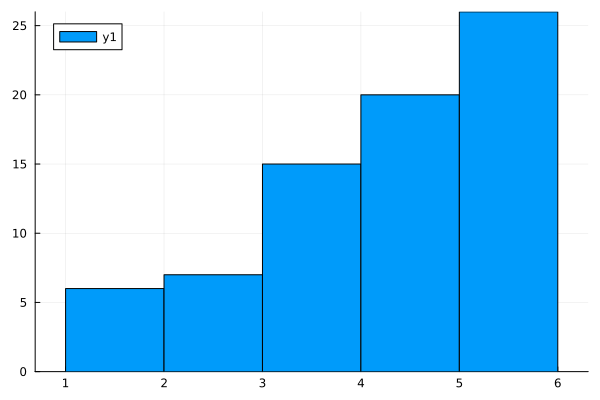

In [11]:
histogram(complete_case_data[!,"task2.exit_space_10"])

# One analysis per question

We try to run one regression per question, to see how AI influences answers for each question. 

In [12]:
# Analysing question 1
model_0 = Models.productivity_analysis_question(
    complete_case_data[!,"task2.exit_space_1"],
    complete_case_data[!,"task1.ai"]
)

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_question), (:answers, :ai_use), (), (), Tuple{Vector{Float64}, Vector{Bool}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_question, (answers = [4.0, 5.0, 5.0, 5.0, 5.0, 4.0, 5.0, 5.0, 5.0, 4.0  …  4.0, 4.0, 5.0, 4.0, 5.0, 5.0, 3.0, 4.0, 5.0, 5.0], ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), NamedTuple(), DynamicPPL.DefaultContext())

In [13]:
chain_0 = sample(model_0, NUTS(), MCMCThreads(), 2000, 4)

┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:03


Chains MCMC chain (2000×19×4 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 4
Samples per chain = 2000
Wall duration     = 8.97 seconds
Compute duration  = 35.59 seconds
parameters        = intercept, effect_ai, offsets[1], offsets[2], offsets[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


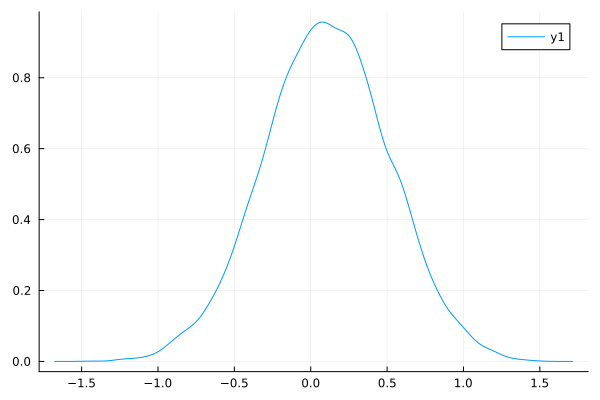

In [14]:
density(vec(chain_0[:effect_ai]))

In [15]:
# Each question has cutoffs.
cutoffs_q1 = vec(generated_quantities(model_0, chain_0))

mean_cutoffs_q1 = map(transpose, cutoffs_q1) |>
    vecs -> reduce(vcat, vecs) |>
    matrix -> mean(matrix, dims=1)

1×4 Matrix{Float64}:
 0.0  0.721147  1.57288  3.42563

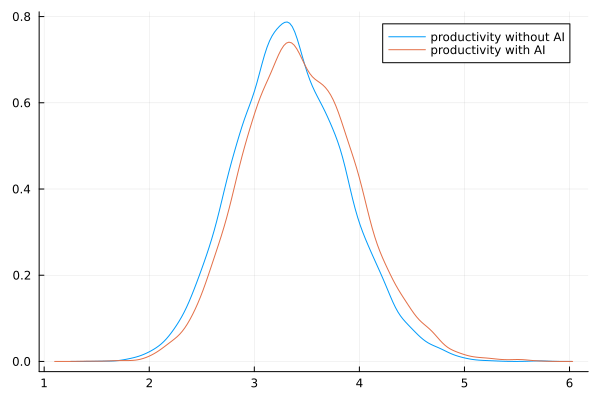

In [16]:
density(chain_0[:intercept] |> vec, label="productivity without AI")
density!(chain_0[:intercept] .+ chain_0[:effect_ai] |> vec, label="productivity with AI")

We don't see any clear difference between the inferred productivities.

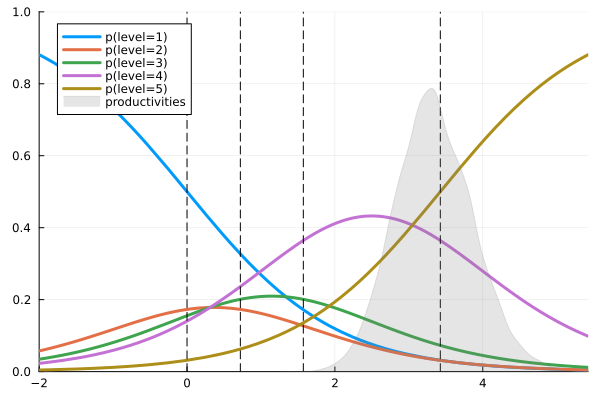

In [17]:
response_q1_0 = Commons.plot_item_response_curves(mean_cutoffs_q1 |> vec)
density!(chain_0[:intercept] |> vec, 
    color=:grey, fill=true, opacity=0.2, 
    label="productivities")

We can see where the inferred "productivity scores" are, and that responses 4 and 5 are most likely. This is consistent with the responses we saw in the questionnaire. 

We can see that the distance between each level is different. We can see that the box for "agree" (level 4 to 5) is bigger than the one for "disagree" (level 1 to 2) .

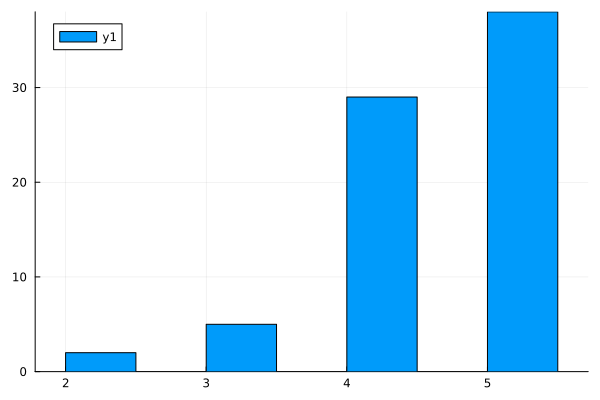

In [18]:
histogram(complete_case_data[!,"task2.exit_space_1"])

In [19]:
# We do this for all the questions...
function mk_model(data, question)
    m = Models.productivity_analysis_question(
        data[!,"task2.exit_space_$question"],
        data[!,"task1.ai"]) 
    return m
end

function mk_chain(m)
    c = sample(m, NUTS(), MCMCThreads(), 1000, 4)
    return c
end

questions = 1:10
models = map(q -> mk_model(complete_case_data, q), questions)
chains = map(mk_chain, models)

┌ Info: Found initial step size
└   ϵ = 0.5261718750000001
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0

10-element Vector{Chains{Float64, AxisArrays.AxisArray{Float64, 3, Array{Float64, 3}, Tuple{AxisArrays.Axis{:iter, StepRange{Int64, Int64}}, AxisArrays.Axis{:var, Vector{Symbol}}, AxisArrays.Axis{:chain, UnitRange{Int64}}}}, Missing, @NamedTuple{parameters::Vector{Symbol}, internals::Vector{Symbol}}, @NamedTuple{varname_to_symbol::OrderedDict{AbstractPPL.VarName, Symbol}, start_time::Vector{Float64}, stop_time::Vector{Float64}, samplerstate::Vector{Nothing}}}}:
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})
 MCMC chain (1000×19×4 Array{Float64, 3})

In [20]:
function get_mean_cutoffs(model, chain)
    mean_cutoffs = vec(generated_quantities(model, chain)) |>
        vecs -> reduce(vcat, vecs') |>
        m -> mean(m, dims=1)
    return mean_cutoffs
end

get_mean_cutoffs (generic function with 1 method)

In [21]:
all_cutoffs = [get_mean_cutoffs(models[i], chains[i])
               for i in 1:10]

10-element Vector{Matrix{Float64}}:
 [0.0 0.7242136952091223 1.5825533525911593 3.435808975239628]
 [0.0 0.7563427928334256 2.1465098997301846 4.005747075616944]
 [0.0 0.8988939423076312 2.0493837390151546 3.366910170806435]
 [0.0 1.3136503985298411 1.956020966184467 3.444119515362842]
 [0.0 0.7811269120134263 1.9411663538190664 3.8862493835362137]
 [0.0 1.0078053982836264 2.333719139431273 4.5842913770664895]
 [0.0 0.31423950374108156 1.881790598668673 3.551361861470818]
 [0.0 1.002251756120202 1.6207267975803 3.4415100205882627]
 [0.0 0.48717257968254624 2.4797850084668798 3.698870638625544]
 [0.0 0.8103013357551927 1.8149598666482751 2.9217591410655612]

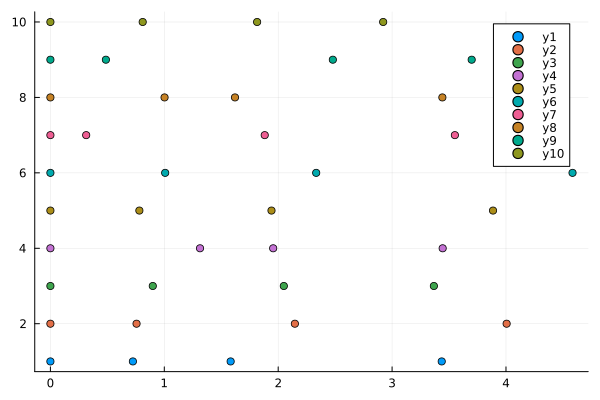

In [22]:
p = plot()

for q in 1:10
    cs = all_cutoffs[q]
    scatter!(p, vec(cs) , [q], color=q)
end
p

In [23]:
cutoff_plots = map(v -> Commons.plot_item_response_curves(vec(v)), all_cutoffs)

10-element Vector{Plots.Plot{Plots.GRBackend}}:
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}
 Plot{Plots.GRBackend() n=6}

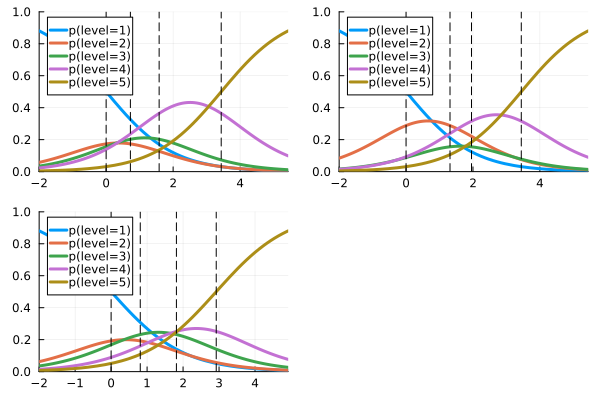

In [24]:
plot(cutoff_plots[[1, 4, 10]]...)

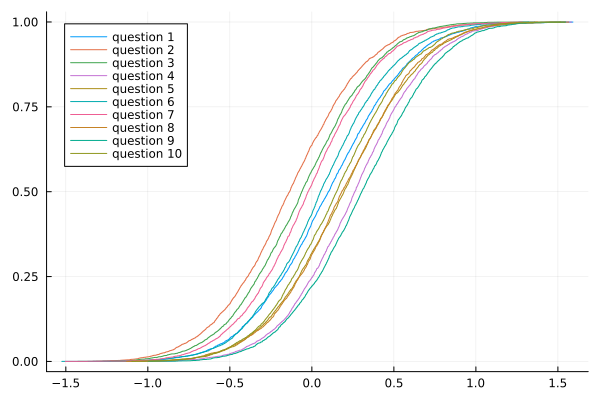

In [25]:
p = plot()

for q in questions
    c = chains[q]
    samples = c[:effect_ai]
    ecdfplot!(p, vec(samples), label="question $q")
end

p

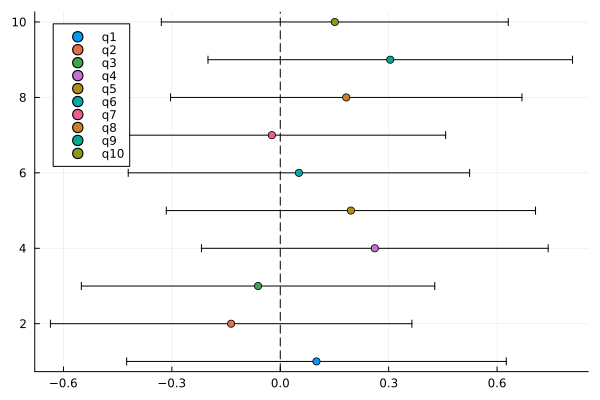

In [26]:
p = plot()

for q in questions
    c = chains[q]
    samples = c[:effect_ai] 
    mu = median(samples)
    sig = quantile(samples, [0.1, 0.9]) .- mu
    scatter!(p, [mu], [q], xerror=sig, label="q$q")
end

Commons.plotzero!(p)
p

We don't see a clear signinificant effect of AI, for any of the questions. 

# Productivity with controls

This is deprecated.

In [27]:
model_1 = Models.productivity_analysis_question_with_controls(
    complete_case_data[!,"task2.exit_space_1"],
    complete_case_data[!,"task1.ai"],
    complete_case_data[!,"task1.ai_xp"],
    Commons.dev1_skill_to_indexes(complete_case_data[!,"task1.entry_demo_5"])
    )

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_question_with_controls), (:answers, :ai_use, :ai_xp, :dev1exp), (), (), Tuple{Vector{Float64}, Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_question_with_controls, (answers = [4.0, 5.0, 5.0, 5.0, 5.0, 4.0, 5.0, 5.0, 5.0, 4.0  …  4.0, 4.0, 5.0, 4.0, 5.0, 5.0, 3.0, 4.0, 5.0, 5.0], ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1exp = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3]), NamedTuple(), DynamicPPL.DefaultContext())

In [28]:
chain_1 = sample(model_1, NUTS(0.7), MCMCThreads(), 2000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:10


Chains MCMC chain (2000×29×4 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 4
Samples per chain = 2000
Wall duration     = 15.6 seconds
Compute duration  = 56.07 seconds
parameters        = intercept, effect_ai, sigma_effect_ai_xp, slopes_ai_xp_z[1], slopes_ai_xp_z[2], slopes_ai_xp_z[3], slopes_ai_xp_z[4], slopes_ai_xp_z[5], sigma_dev1_skill, slopes_dev1exp_z[1], slopes_dev1exp_z[2], slopes_dev1exp_z[3], offsets[1], offsets[2], offsets[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [29]:
ess_rhat(chain_1)

ESS/R-hat
           parameters         ess      rhat   ess_per_sec 
               Symbol     Float64   Float64       Float64 

            intercept    139.8581    1.0394        2.4944
            effect_ai    535.4303    1.0118        9.5497
   sigma_effect_ai_xp    800.0336    1.0089       14.2690
    slopes_ai_xp_z[1]   2067.5467    1.0495       36.8757
    slopes_ai_xp_z[2]    187.6348    1.0317        3.3466
    slopes_ai_xp_z[3]   1672.7441    1.0124       29.8342
    slopes_ai_xp_z[4]   1493.0290    1.0122       26.6289
    slopes_ai_xp_z[5]    618.1563    1.0116       11.0251
     sigma_dev1_skill    196.2351    1.0300        3.4999
  slopes_dev1exp_z[1]    288.7304    1.0200        5.1496
  slopes_dev1exp_z[2]    224.8169    1.0249        4.0097
  slopes_dev1exp_z[3]    297.7352    1.0189        5.3103
           offsets[1]    292.5748    1.0313        5.2182
           offsets[2]     99.7392    1.0484        1.7789
           offsets[3]   2104.5963    1.0318       37.5365


The sampling is pretty bad for question 1, wonder why that is... (We use a model with z-scores, that samples less well than the model with monotonic effects, which we use when considering all questions)

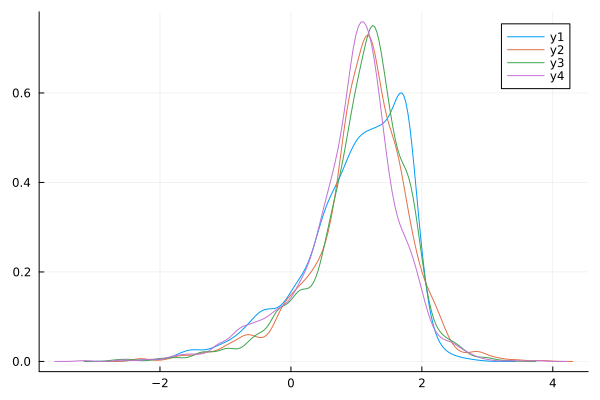

In [30]:
density(chain_1["slopes_dev1exp_z[1]"])

In [31]:
# We do this for all the questions...
function mk_chain_wc(data, question)
    m = Models.productivity_analysis_question_with_controls(
        data[!,"task2.exit_space_$question"],
        data[!,"task1.ai"],
        data[!,"task1.ai_xp"],
        Commons.dev1_skill_to_indexes(data[!,"task1.entry_demo_5"]))
    
    c = sample(m, NUTS(), MCMCThreads(), 2000, 4)
    return c
end


chains = map(q -> mk_chain_wc(complete_case_data, q),
             questions)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:07
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:07
┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:05
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:04
┌ Info

10-element Vector{Chains{Float64, AxisArrays.AxisArray{Float64, 3, Array{Float64, 3}, Tuple{AxisArrays.Axis{:iter, StepRange{Int64, Int64}}, AxisArrays.Axis{:var, Vector{Symbol}}, AxisArrays.Axis{:chain, UnitRange{Int64}}}}, Missing, @NamedTuple{parameters::Vector{Symbol}, internals::Vector{Symbol}}, @NamedTuple{varname_to_symbol::OrderedDict{AbstractPPL.VarName, Symbol}, start_time::Vector{Float64}, stop_time::Vector{Float64}, samplerstate::Vector{Nothing}}}}:
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})
 MCMC chain (2000×29×4 Array{Float64, 3})

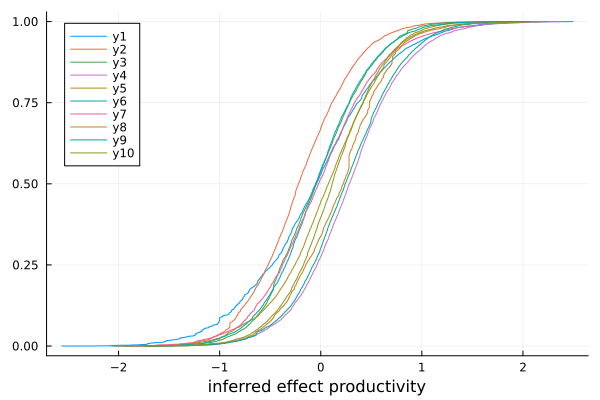

In [32]:
p = plot()

for q in questions
    c = chains[q]
    samples = vec(c[:effect_ai])
    ecdfplot!(p, samples, xlabel="inferred effect productivity")
end

p

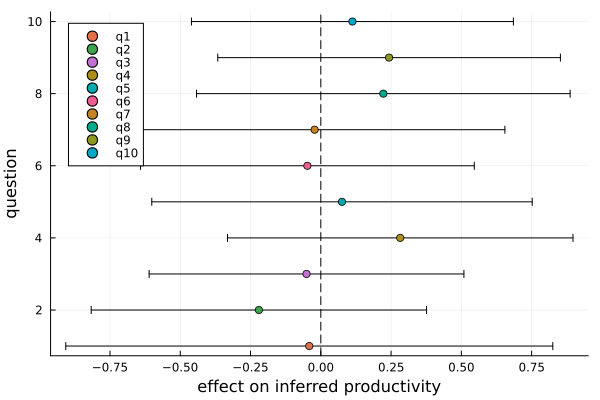

In [33]:
p = plot()

vline!(p, [0.0], style=:dash, color=:black, label=missing)

for q in questions
    c = chains[q]
    samples = vec(c[:effect_ai])
    middle = median(samples)
    error = quantile(samples, [0.1, 0.9]) .- middle
    scatter!(p, [middle], [q], xerror=error, label="q$q",
        xlabel="effect on inferred productivity",
        ylabel="question")
end
p

... This doesn't tell us much. No significant values.

# Putting all questions into a single model

Instead, of making one regression per question, we will try to pool the information from all the questions into a single model. 

In [34]:
productivities1 = Matrix(complete_case_data[!,[c for c in outcomes if occursin("task1", string(c))]])
productivities2 = Matrix(complete_case_data[!,[c for c in outcomes if occursin("task2", string(c))]])

74×10 Matrix{Float64}:
 4.0  4.0  1.0  1.0  5.0  4.0  1.0  2.0  3.0  5.0
 5.0  4.0  3.0  5.0  4.0  5.0  5.0  5.0  5.0  4.0
 5.0  4.0  5.0  2.0  4.0  4.0  4.0  5.0  4.0  2.0
 5.0  5.0  5.0  4.0  5.0  4.0  5.0  5.0  5.0  1.0
 5.0  3.0  4.0  4.0  4.0  3.0  3.0  4.0  5.0  3.0
 4.0  4.0  1.0  1.0  5.0  4.0  1.0  2.0  3.0  5.0
 5.0  4.0  3.0  5.0  4.0  5.0  5.0  5.0  5.0  4.0
 5.0  4.0  5.0  2.0  4.0  4.0  4.0  5.0  4.0  2.0
 5.0  5.0  5.0  4.0  5.0  4.0  5.0  5.0  5.0  1.0
 4.0  4.0  5.0  4.0  3.0  4.0  4.0  5.0  3.0  4.0
 5.0  5.0  4.0  4.0  5.0  3.0  5.0  5.0  5.0  4.0
 4.0  3.0  3.0  2.0  3.0  3.0  4.0  4.0  3.0  4.0
 5.0  4.0  5.0  4.0  4.0  4.0  3.0  5.0  4.0  5.0
 ⋮                        ⋮                   
 5.0  3.0  5.0  4.0  4.0  4.0  5.0  5.0  4.0  1.0
 5.0  4.0  4.0  5.0  4.0  4.0  4.0  4.0  4.0  5.0
 4.0  4.0  4.0  5.0  5.0  4.0  5.0  5.0  5.0  4.0
 4.0  3.0  5.0  3.0  4.0  4.0  4.0  5.0  3.0  1.0
 5.0  5.0  3.0  4.0  5.0  4.0  4.0  4.0  5.0  5.0
 4.0  4.0  4.0  2.0  3.0  4.0 

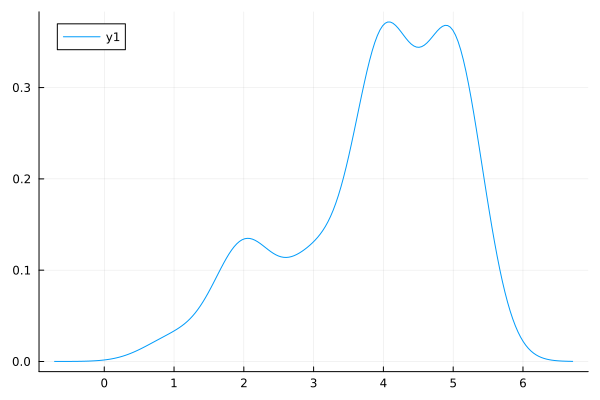

In [35]:
density(productivities2[:, 4])

In [36]:
# Doesn't work anymore, becauce of incompatiblity things in Python
# using ArviZ, ArviZPythonPlots

In [37]:
model_3 = Models.productivity_analysis(
    5, 
    complete_case_data[!,"task1.ai"], 
    productivities2)

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis), (:n_levels, :ai_use, :answers), (), (), Tuple{Int64, Vector{Bool}, Matrix{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis, (n_levels = 5, ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], answers = [4.0 4.0 … 3.0 5.0; 5.0 4.0 … 5.0 4.0; … ; 5.0 5.0 … 5.0 3.0; 5.0 5.0 … 5.0 5.0]), NamedTuple(), DynamicPPL.DefaultContext())

In [38]:
chain_3 = sample(model_3, NUTS(), MCMCThreads(), 1000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:26


Chains MCMC chain (1000×46×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 29.39 seconds
Compute duration  = 111.78 seconds
parameters        = intercept, effect_ai, offsets[1, 1], offsets[2, 1], offsets[3, 1], offsets[4, 1], offsets[5, 1], offsets[6, 1], offsets[7, 1], offsets[8, 1], offsets[9, 1], offsets[10, 1], offsets[1, 2], offsets[2, 2], offsets[3, 2], offsets[4, 2], offsets[5, 2], offsets[6, 2], offsets[7, 2], offsets[8, 2], offsets[9, 2], offsets[10, 2], offsets[1, 3], offsets[2, 3], offsets[3, 3], offsets[4, 3], offsets[5, 3], offsets[6, 3], offsets[7, 3], offsets[8, 3], offsets[9, 3], offsets[10, 3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [39]:
ess_rhat(chain_3)

ESS/R-hat
      parameters         ess      rhat   ess_per_sec 
          Symbol     Float64   Float64       Float64 

       intercept   2618.4239    1.0000       23.4256
       effect_ai   6992.3128    1.0010       62.5565
   offsets[1, 1]   3425.5179    0.9997       30.6463
   offsets[2, 1]   3095.3002    0.9994       27.6920
   offsets[3, 1]   4141.4482    0.9999       37.0513
   offsets[4, 1]   3721.9651    1.0012       33.2984
   offsets[5, 1]   3551.1616    0.9997       31.7703
   offsets[6, 1]   3636.9507    0.9997       32.5379
   offsets[7, 1]   3249.2673    1.0006       29.0695
   offsets[8, 1]   3587.8345    1.0009       32.0984
   offsets[9, 1]   3286.0954    1.0017       29.3989
  offsets[10, 1]   3539.7867    1.0003       31.6686
   offsets[1, 2]   4694.6380    1.0007       42.0004
   offsets[2, 2]   4216.6391    0.9994       37.7240
   offsets[3, 2]   5155.6317    0.9996       46.1247
   offsets[4, 2]   5365.3018    1.0014       48.0005
   offsets[5, 2]   4116.0970    1

Sampling is effective (if slow)

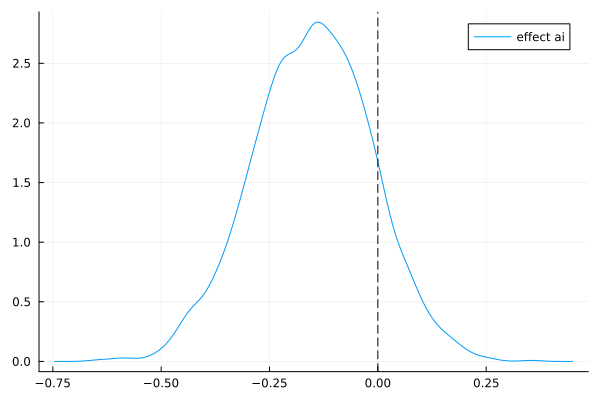

In [40]:
p = density(vec(chain_3[:effect_ai]), label="effect ai")
Commons.plotzero!(p)
p

In [41]:
Commons.probability_direction(chain_3[:effect_ai])

0.8695

When we include all the questions into one model, we see that when dev1 was in the using AI group, dev2 felt slightly less productive (but not significantly). 

In [42]:
cutoffs_all = vec(generated_quantities(model_3, chain_3));

In [43]:
mean_cutoffs = 
    cutoffs_all |>
    cutoffs -> map(m -> m[1,:], cutoffs) |>
    vecs -> map(transpose, vecs) |>
    vecs -> reduce(vcat, vecs) |>
    mat -> mean(mat, dims=1)
# mean_cutoffs = map(transpose, cutoffs) |>
#     vecs -> reduce(vcat, vecs)
    # matrix -> mean(matrix, dims=1)

1×4 Matrix{Float64}:
 0.0  0.766457  1.66403  3.56383

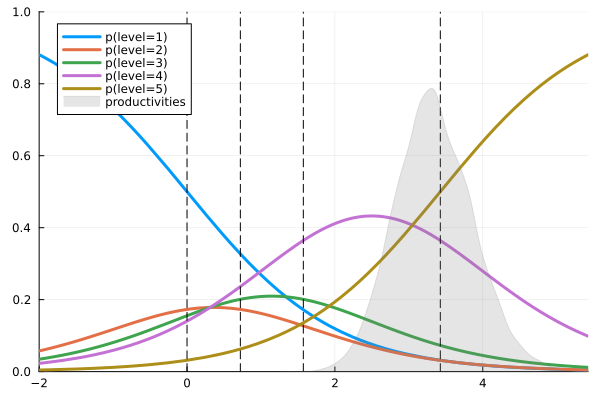

In [44]:
response_q1_0

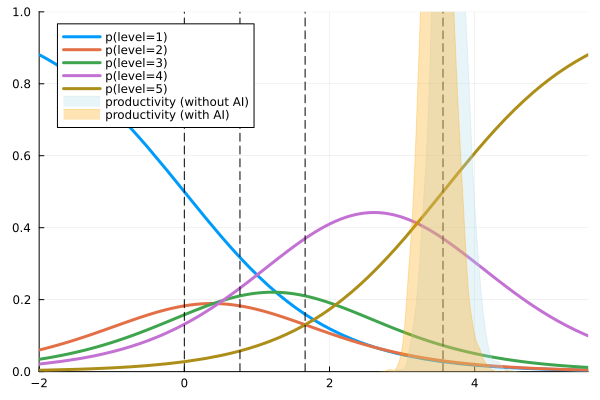

In [45]:
Commons.plot_item_response_curves(vec(mean_cutoffs))
density!(chain_3[:intercept] |> vec, color=:lightblue, fill=true, opacity=0.3, 
    label="productivity (without AI)")
density!(chain_3[:intercept] .+ chain_3[:effect_ai] |> vec, color=:orange, fill=true, opacity=0.3, 
    label="productivity (with AI)")

We can see that the cutoffs moved a little bit when we include all the questions and that the estimated productivities have much tighter distributions. Also, we see that they're a bit lower when dev1 used AI.

We can also see the productivities are around 3-4, and that at that level, the most probable answers are 4 and 5, which is what we see in the data: 

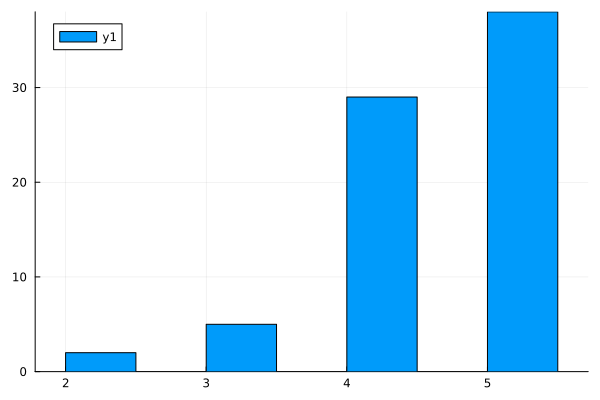

In [46]:
histogram(complete_case_data[!,"task2.exit_space_1"])

## All questions in one model, with controls.

In [47]:
model_4 = Models.productivity_analysis_with_controls_2(
    5,
    complete_case_data[!,"task1.ai"], 
    complete_case_data[!,"task1.ai_xp"],
    Commons.dev1_skill_to_indexes(complete_case_data[!,"task1.entry_demo_5"]),
    productivities2)

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_with_controls_2), (:n_levels, :ai_use, :ai_xp, :dev1exp, :answers, :prior_effect_ai), (), (), Tuple{Int64, Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Matrix{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_with_controls_2, (n_levels = 5, ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1exp = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], answers = [4.0 4.0 … 3.0 5.0; 5.0 4.0 … 5.0 4.0; … ; 5.0 5.0 … 5.0 3.0; 5.0 5.0 … 5.0 5.0], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

The model is a bit slow. 

In [98]:
# This takes a while
chain_4 = sample(model_4, NUTS(), MCMCThreads(), 4000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:05:35


Chains MCMC chain (4000×62×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 341.46 seconds
Compute duration  = 1167.04 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, offsets[1, 1], offsets[2, 1], offsets[3, 1], offsets[4, 1], offsets[5, 1], offsets[6, 1], offsets[7, 1], offsets[8, 1], offsets[9, 1], offsets[10, 1], offsets[1, 2], offsets[2, 2], offsets[3, 2], offsets[4, 2], offsets[5, 2], offsets[6, 2], offsets[7, 2], offsets[8, 2], offsets[9, 2], offsets[10, 2], offsets[1, 3], offsets[2, 3], offsets[3, 3], offsets[4, 3], offsets[5, 3], offsets[6, 3], offsets[7, 3], offsets[8, 3], offsets[9, 3], offsets[10, 3], std_prod

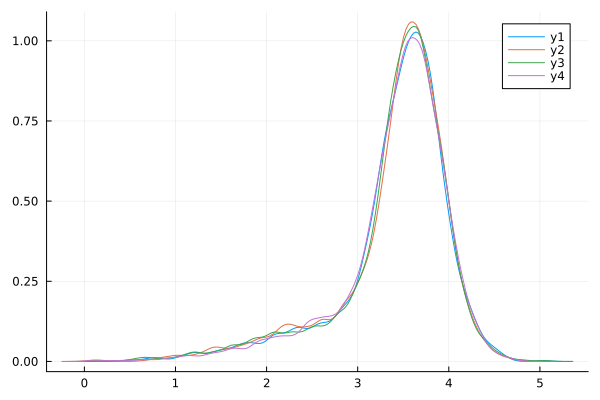

In [99]:
density(chain_4["intercept"])

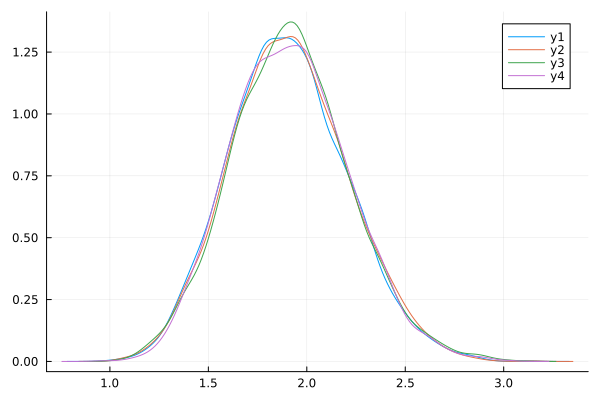

In [100]:
density(chain_4["offsets[1, 3]"])

In [101]:
DataFrame(ess_rhat(chain_4)) |> df -> sort(df, :ess)

Row,parameters,ess,rhat,ess_per_sec
,Symbol,Float64,Float64,Float64
1,effect_dev1_skill[1],4909.45,1.00033,4.20676
2,intercept,5075.49,1.00013,4.34904
3,effect_dev1_skill[2],5095.04,1.00023,4.36579
4,effect_skill,5263.05,1.00017,4.50976
5,effect_dev1_skill[3],5263.05,1.00017,4.50976
6,effect_skill_factor[1],5702.46,1.00055,4.88628
7,standardized_effect_skill,7090.27,1.00006,6.07545
8,effect_skill_factor[2],7224.41,1.00019,6.19039
9,effect_skill_difference,7494.59,0.999991,6.4219


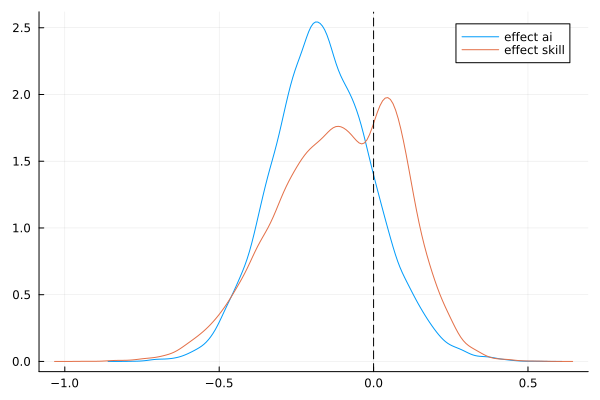

In [102]:
density(chain_4[:effect_ai] |> vec, label="effect ai") 
density!(chain_4[:effect_skill_difference] |> vec, label="effect skill") |> Commons.plotzero!

In [108]:
Commons.posterior_summary(chain_4[:effect_ai], direction=(<))

(p_delta = 0.84, mean = -0.16, interval_95 = [-0.48, 0.17])

In [109]:
Commons.posterior_summary(chain_4[:standardized_effect_ai], direction=(<))

(p_delta = 0.84, mean = -1.26, interval_95 = [-2.46, 2.31])

We don't see a significant effect...

In [113]:
Commons.posterior_summary(chain_4[:effect_skill_difference], direction=(<))

(p_delta = 0.66, mean = -0.11, interval_95 = [-0.52, 0.23])

In [114]:
Commons.posterior_summary(chain_4[:standardized_effect_skill], direction=(<))

(p_delta = 0.66, mean = -0.77, interval_95 = [-2.82, 2.58])

In [115]:
Commons.probability_direction(chain_4[:effect_ai], compare=(>))

0.1559375

We conclude there is a probability of 85% that AI has a negative effect on productivity of dev2. But the difference is not significant. 

In [116]:
Commons.posterior_summary(vec(chain_4[:effect_ai]))

(p_delta = 0.84, mean = -0.16, interval_95 = [-0.48, 0.17])

## Plots to explain the inference

In this section, we scale the effect by the standard dev of the inferred productivities. That way, that makes the results a bit easier to understand. 

In [117]:
quantities = generated_quantities(model_4, chain_4) |> vec;

cutoffs = map(t -> t[:cutoffs], quantities)
productivities_ = map(t -> t[:productivities_], quantities)
effects_ai_xp = map(t -> t[:effect_ai_xp], quantities)
effects_skill = map(t -> t[:effect_skill], quantities)
effects_ai_xp_standardized = map(t -> t[:standardized_effect_ai], quantities)

16000-element Vector{Float64}:
 -0.932929360830918
 -1.8037780839121376
 -1.375486376799245
 -2.059379229409918
 -1.3731673341511694
 -0.8857755705641905
 -1.6145352028388396
 -2.0121285435159897
 -0.423482500364652
 -1.5954909158732635
 -1.3850950452204709
 -2.161204248736842
 -1.189943724649852
  ⋮
 -1.7364438628217649
 -2.4731525227367643
 -2.215265850353
 -0.7475037133171655
 -2.38171408478519
  1.8015133119284605
 -1.9162311374445262
  0.5408327891059841
 -2.3701647785460533
 -0.2783984304653317
 -2.1653416150867546
  0.1538497311327446

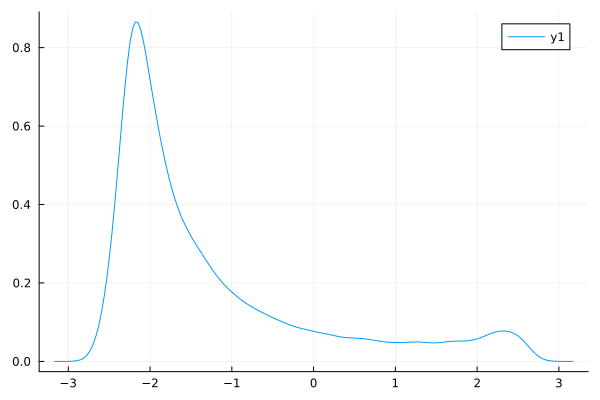

In [119]:
# Plotting the effect of AI, in STD-devs of productivity
density(vec(chain_4[:standardized_effect_ai]))

This plot is a bit strange 


Not significant

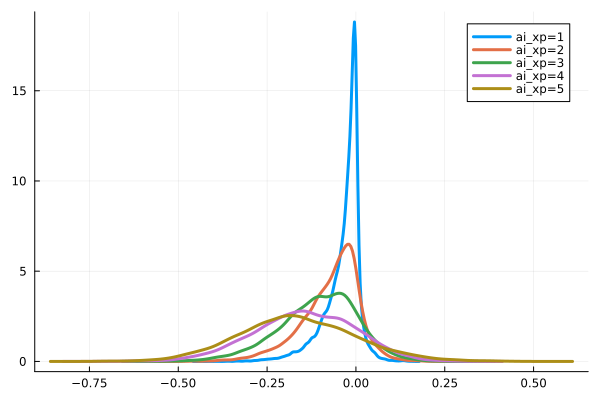

In [120]:
p = plot()

for ai_xp in 1:5
    density!(p, [v[ai_xp] for v in effects_ai_xp], label="ai_xp=$ai_xp", lw=3)
end
p

In [121]:
Plots.savefig(p, "effect_ai_productivity.pdf")

"/home/noric/Dev/echoes-of-ai-emse-2025/bayesian/notebooks/effect_ai_productivity.pdf"

We see a detrimental effect of AIxp from dev1 on the perceived productivity of dev2. More experience, worse effect.

In [122]:
filter(r -> r["task1.entry_demo_5"] == "Beginner", complete_case_data)

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10
,Bool,Int64,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,1.0,1.0,5.0,4.0,1.0,2.0,3.0,5.0
2,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,3.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0
3,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,4.0,4.0,4.0,5.0,4.0,2.0
4,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,5.0,1.0
5,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,1.0,1.0,5.0,4.0,1.0,2.0,3.0,5.0
6,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,3.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0
7,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,4.0,4.0,4.0,5.0,4.0,2.0
8,true,5,Beginner,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,5.0,1.0
9,true,4,Beginner,3.0,4.0,3.0,2.0,5.0,3.0,2.0,5.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,3.0,4.0,4.0,3.0,4.0


Note that we **only** gave AI to the devs with high experience. So the effects we see are all inferred from the people with high skill in AI. 

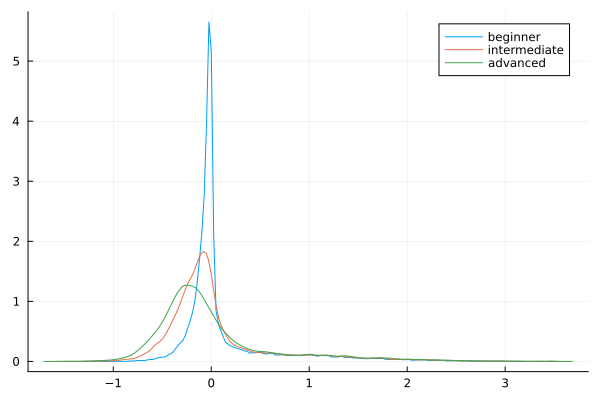

In [127]:
density(vec(chain_4["effect_dev1_skill[1]"]), label="beginner")
density!(vec(chain_4["effect_dev1_skill[2]"]), label="intermediate")
density!(vec(chain_4["effect_dev1_skill[3]"]), label="advanced")

We don't see a significant effect of skill on perceived productivity.

There's a lot of uncertainty about the effect of high skill. It seems it can be very positive, but also is usually negative.

In [129]:
# Let's look at the scale
prods = reduce(vcat, productivities_)

cutoff_q1 = map(cs -> cs[1,:], cutoffs) |> vs -> reduce(hcat, vs) |> m -> mean(m, dims=2)

4×1 Matrix{Float64}:
 0.0
 0.6305555715516094
 1.4442891906992792
 3.356982921348862

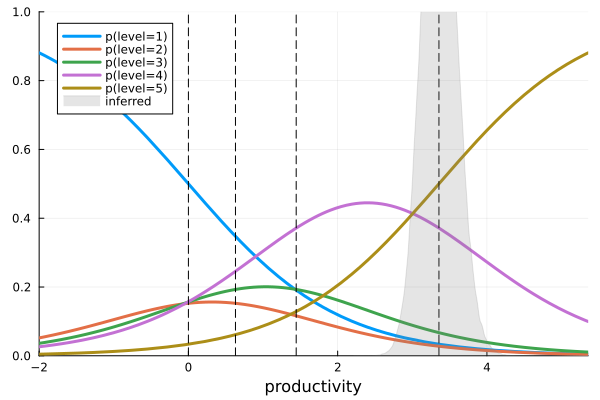

In [130]:
p1 = Commons.plot_item_response_curves(vec(cutoff_q1))
density!(p1, prods, color=:gray, fill=true, opacity=0.2, xlabel="productivity",
        label="inferred")

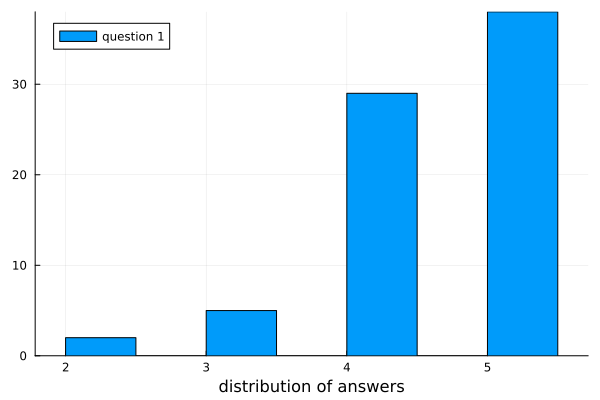

In [131]:
p2 = histogram(complete_case_data[!,"task2.exit_space_1"], xlabel="distribution of answers", label="question 1")

In [132]:
Plots.savefig(plot(p1, p2, size=(800, 500)), "productivity_plot.pdf")

"/home/noric/Dev/echoes-of-ai-emse-2025/bayesian/notebooks/productivity_plot.pdf"

We can see that if we look at the inferred productivities, most of the answers for question 1 should be levels 4 and 5, with a few 2's and 3's. We can see that this matches the answers we obtained.

# Counterfactual simulations

In [73]:
model_4_predict = Models.productivity_analysis_with_controls_2(
    5,
    [0, 1],  
    [5, 5], # AI XP
    [3, 3], # SKILL
    fill(missing, 2, 10))

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_with_controls_2), (:n_levels, :ai_use, :ai_xp, :dev1exp, :answers, :prior_effect_ai), (), (), Tuple{Int64, Vector{Int64}, Vector{Int64}, Vector{Int64}, Matrix{Missing}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_with_controls_2, (n_levels = 5, ai_use = [0, 1], ai_xp = [5, 5], dev1exp = [3, 3], answers = [missing missing … missing missing; missing missing … missing missing], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

In [74]:
# Table for each level, for each question, the probability difference between the two groups

differences = []

for replication in 1:10
    predictions = predict(model_4_predict, chain_4)
    for level in 1:5
        for question in 1:10
            v1 = vec(predictions["answers[1, $question]"])
            v2 = vec(predictions["answers[2, $question]"])
            p1 = v1 .== level
            p2 = v2 .== level
            difference = mean(p2) - mean(p1)
            append!(differences, [(;p_with_ai=mean(p2), p_without_ai=mean(p1),
                        level, question, difference, replication)])
        end
    end
end

differences = DataFrame(differences)

Row,p_with_ai,p_without_ai,level,question,difference,replication
,Float64,Float64,Int64,Int64,Float64,Int64
1,0.04075,0.034,1,1,0.00675,1
2,0.037,0.03475,1,2,0.00225,1
3,0.039,0.03825,1,3,0.00075,1
4,0.0415,0.03175,1,4,0.00975,1
5,0.03875,0.03125,1,5,0.0075,1
6,0.04025,0.035,1,6,0.00525,1
7,0.042,0.03375,1,7,0.00825,1
8,0.0405,0.03075,1,8,0.00975,1
9,0.03625,0.03125,1,9,0.005,1


In [75]:
combine(groupby(differences, [:question, :level]), [:p_with_ai, :p_without_ai, :difference] .=> [mean]) |>
    df -> sort(df, :difference_mean)

Row,question,level,p_with_ai_mean,p_without_ai_mean,difference_mean
,Int64,Int64,Float64,Float64,Float64
1,10,5,0.3476,0.38845,-0.04085
2,4,5,0.3451,0.383275,-0.038175
3,8,5,0.460575,0.497125,-0.03655
4,1,5,0.476575,0.5126,-0.036025
5,3,5,0.376175,0.410975,-0.0348
6,5,5,0.29895,0.333675,-0.034725
7,9,5,0.339275,0.37395,-0.034675
8,7,5,0.25795,0.291325,-0.033375
9,2,5,0.263425,0.291775,-0.02835


In [76]:
using VegaLite

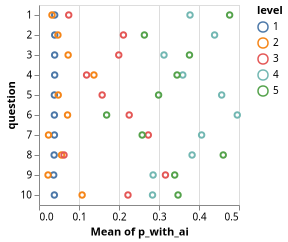

In [77]:
differences |> @vlplot(:point, y="question:O", color="level:N", x="mean(p_with_ai)")

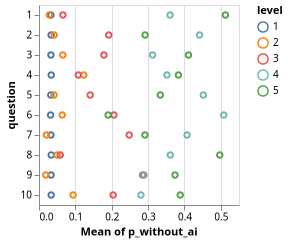

In [78]:
differences |> @vlplot(:point, y="question:O", color="level:N", x="mean(p_without_ai)")

We can see the effect is quite small. 

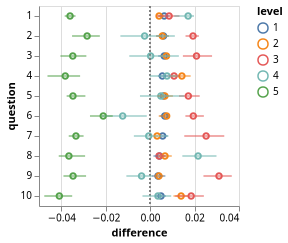

In [79]:
p = differences |> @vlplot(:point, y="question:O", color="level:N") + 
    @vlplot(:point, x="mean(difference)") + 
    @vlplot(mark={type=:rule, strokeDash=[2,2]}, x={datum=0.0}, y={value=0}, y2={value="height"}, 
        color={value="grey"}) +
    @vlplot(mark={type=:errorbar, extent="iqr"}, y="question:O", x="difference")

In [80]:
VegaLite.savefig("plot_productivity_diff.pdf", p)

# Comparison with Task1

In [133]:
model_4_task1 = Models.productivity_analysis_with_controls_2(
    5,
    complete_case_data[!,"task1.ai"], 
    complete_case_data[!,"task1.ai_xp"],
    Commons.dev1_skill_to_indexes(complete_case_data[!,"task1.entry_demo_5"]),
    productivities1)

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_with_controls_2), (:n_levels, :ai_use, :ai_xp, :dev1exp, :answers, :prior_effect_ai), (), (), Tuple{Int64, Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Matrix{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_with_controls_2, (n_levels = 5, ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1exp = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], answers = [5.0 5.0 … 5.0 5.0; 5.0 5.0 … 5.0 5.0; … ; 4.0 4.0 … 3.0 4.0; 4.0 4.0 … 3.0 4.0], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

In [134]:
chain_4_task1 = sample(model_4_task1, NUTS(), MCMCThreads(), 1000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:57


Chains MCMC chain (1000×62×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 58.75 seconds
Compute duration  = 228.46 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, offsets[1, 1], offsets[2, 1], offsets[3, 1], offsets[4, 1], offsets[5, 1], offsets[6, 1], offsets[7, 1], offsets[8, 1], offsets[9, 1], offsets[10, 1], offsets[1, 2], offsets[2, 2], offsets[3, 2], offsets[4, 2], offsets[5, 2], offsets[6, 2], offsets[7, 2], offsets[8, 2], offsets[9, 2], offsets[10, 2], offsets[1, 3], offsets[2, 3], offsets[3, 3], offsets[4, 3], offsets[5, 3], offsets[6, 3], offsets[7, 3], offsets[8, 3], offsets[9, 3], offsets[10, 3], std_product

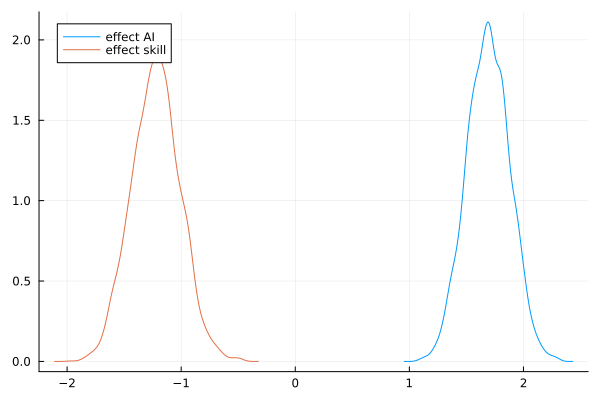

In [143]:
density(vec(chain_4_task1[:effect_ai]), label="effect AI")
density!(vec(chain_4_task1[:effect_skill_difference]), label="effect skill")

In [136]:
Commons.posterior_summary(vec(chain_4_task1[:effect_ai]))

(p_delta = 0.0, mean = 1.69, interval_95 = [1.33, 2.06])

In [137]:
Commons.posterior_summary(chain_4_task1[:standardized_effect_ai])

(p_delta = 0.0, mean = 1.71, interval_95 = [1.44, 1.97])

In [138]:
Commons.probability_direction(chain_4_task1[:effect_ai], compare=(<))

0.0

We find that the probability that AI improved productivity in task 1 is pretty much 100%. 

In [144]:
Commons.posterior_summary(chain_4_task1[:effect_skill_difference], direction=(<))

(p_delta = 1.0, mean = -1.22, interval_95 = [-1.63, -0.8])

In [146]:
Commons.posterior_summary(chain_4_task1[:standardized_effect_skill], direction=(<))

(p_delta = 1.0, mean = -1.24, interval_95 = [-1.58, -0.87])

# Sensitivity Analysis

In [147]:
std(prods)

0.22673972465573336

In [148]:
model_4_optimistic = Models.productivity_analysis_with_controls_2(
    5,
    complete_case_data[!,"task1.ai"], 
    complete_case_data[!,"task1.ai_xp"],
    Commons.dev1_skill_to_indexes(complete_case_data[!,"task1.entry_demo_5"]),
    productivities2, 
    Normal(0.25, 0.5))

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_with_controls_2), (:n_levels, :ai_use, :ai_xp, :dev1exp, :answers, :prior_effect_ai), (), (), Tuple{Int64, Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Matrix{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_with_controls_2, (n_levels = 5, ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1exp = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], answers = [4.0 4.0 … 3.0 5.0; 5.0 4.0 … 5.0 4.0; … ; 5.0 5.0 … 5.0 3.0; 5.0 5.0 … 5.0 5.0], prior_effect_ai = Normal{Float64}(μ=0.25, σ=0.5)), NamedTuple(), DynamicPPL.DefaultContext())

In [149]:
model_4_pessimistic = Models.productivity_analysis_with_controls_2(
    5,
    complete_case_data[!,"task1.ai"], 
    complete_case_data[!,"task1.ai_xp"],
    Commons.dev1_skill_to_indexes(complete_case_data[!,"task1.entry_demo_5"]),
    productivities2, 
    Normal(-0.25, 0.5))

DynamicPPL.Model{typeof(ai_codev_study.Models.productivity_analysis_with_controls_2), (:n_levels, :ai_use, :ai_xp, :dev1exp, :answers, :prior_effect_ai), (), (), Tuple{Int64, Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Matrix{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.productivity_analysis_with_controls_2, (n_levels = 5, ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1exp = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], answers = [4.0 4.0 … 3.0 5.0; 5.0 4.0 … 5.0 4.0; … ; 5.0 5.0 … 5.0 3.0; 5.0 5.0 … 5.0 5.0], prior_effect_ai = Normal{Float64}(μ=-0.25, σ=0.5)), NamedTuple(), DynamicPPL.DefaultContext())

In [150]:
chain_4_optimistic = sample(model_4_optimistic, NUTS(), MCMCThreads(), 500, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:55


Chains MCMC chain (500×62×4 Array{Float64, 3}):

Iterations        = 251:1:750
Number of chains  = 4
Samples per chain = 500
Wall duration     = 55.58 seconds
Compute duration  = 203.1 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, offsets[1, 1], offsets[2, 1], offsets[3, 1], offsets[4, 1], offsets[5, 1], offsets[6, 1], offsets[7, 1], offsets[8, 1], offsets[9, 1], offsets[10, 1], offsets[1, 2], offsets[2, 2], offsets[3, 2], offsets[4, 2], offsets[5, 2], offsets[6, 2], offsets[7, 2], offsets[8, 2], offsets[9, 2], offsets[10, 2], offsets[1, 3], offsets[2, 3], offsets[3, 3], offsets[4, 3], offsets[5, 3], offsets[6, 3], offsets[7, 3], offsets[8, 3], offsets[9, 3], offsets[10, 3], std_productivit

In [151]:
chain_4_pessimistic = sample(model_4_pessimistic, NUTS(), MCMCThreads(), 500, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:01:01


Chains MCMC chain (500×62×4 Array{Float64, 3}):

Iterations        = 251:1:750
Number of chains  = 4
Samples per chain = 500
Wall duration     = 61.93 seconds
Compute duration  = 223.04 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, offsets[1, 1], offsets[2, 1], offsets[3, 1], offsets[4, 1], offsets[5, 1], offsets[6, 1], offsets[7, 1], offsets[8, 1], offsets[9, 1], offsets[10, 1], offsets[1, 2], offsets[2, 2], offsets[3, 2], offsets[4, 2], offsets[5, 2], offsets[6, 2], offsets[7, 2], offsets[8, 2], offsets[9, 2], offsets[10, 2], offsets[1, 3], offsets[2, 3], offsets[3, 3], offsets[4, 3], offsets[5, 3], offsets[6, 3], offsets[7, 3], offsets[8, 3], offsets[9, 3], offsets[10, 3], std_productivi

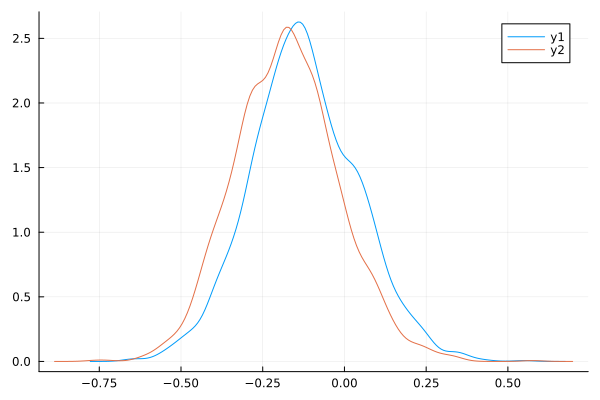

In [153]:
density(chain_4_optimistic[:effect_ai] |> vec)
density!(chain_4_pessimistic[:effect_ai] |> vec)

We see pretty much the same posteriors
